# Portable Baseline Anomaly Detector

**Purpose.** Explain and execute the detector used when a large PaDiM or PatchCore checkpoint is unavailable.

**Expected result.** Real normal and defective images pass through object preprocessing, ResNet18 normal-memory scoring, OpenCV residual localization, and the final two-gate defect decision.

**Platform connection.** This is the portable CPU path used by local clones and lightweight deployment environments.

## Detector design

The portable detector combines two complementary signals:

1. **Global anomaly evidence:** a shared ResNet18 ONNX extractor converts the image into an embedding. The image score is the cosine distance to its nearest normal training embedding.
2. **Spatial anomaly evidence:** the grayscale image is compared with the category's normal mean and standard-deviation profile after brightness correction. Connected-component cleanup removes tiny residual noise.

A product is marked defective only when the global score is above its calibrated threshold **and** a spatial defect region remains. This prevents a high image score without local evidence from becoming an automatic defect.

In [1]:
from pathlib import Path
import json
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import JSON, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "ml").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def locate_mvtec_root() -> Path:
    configured = os.getenv("MVTEC_DATASET_ROOT")
    candidates = [
        Path(configured).expanduser() if configured else None,
        PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai-github" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection1",
    ]
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "MVTec AD was not found. Set MVTEC_DATASET_ROOT or place the dataset under "
        "data/raw/mvtec_anomaly_detection."
    )

DATASET_ROOT = locate_mvtec_root()
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def image_files(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(path for path in directory.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

def first_test_image(category: str, label: str) -> Path:
    paths = image_files(DATASET_ROOT / category / "test" / label)
    if not paths:
        raise FileNotFoundError(f"No {category}/{label} test image was found.")
    return paths[0]

def first_defect(category: str) -> tuple[str, Path]:
    test_root = DATASET_ROOT / category / "test"
    defect_dirs = sorted(path for path in test_root.iterdir() if path.is_dir() and path.name != "good")
    for directory in defect_dirs:
        paths = image_files(directory)
        if paths:
            return directory.name, paths[0]
    raise FileNotFoundError(f"No defective test image was found for {category}.")

def mask_path_for(category: str, label: str, image_path: Path) -> Path | None:
    if label == "good":
        return None
    candidate = DATASET_ROOT / category / "ground_truth" / label / f"{image_path.stem}_mask.png"
    return candidate if candidate.exists() else None

def read_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Project root: {PROJECT_ROOT}")
print(f"MVTec root:  {DATASET_ROOT}")

Project root: C:\Users\HP\Desktop\springboard\VisionInspectAI-team
MVTec root:  C:\Users\HP\Desktop\springboard\visioninspect-ai-github\data\raw\mvtec_anomaly_detection


In [2]:
from dataclasses import replace

from ml.baseline_detector import load_reference_profile
from ml.model_registry import category_model_spec
from ml.predict import build_inference_config

CATEGORY = "cable"
spec = category_model_spec(CATEGORY)
config = replace(
    build_inference_config(CATEGORY),
    use_padim_inference=False,
    use_openvino_inference=False,
    openvino_path=None,
    openvino_calibrator_path=None,
)
profile = load_reference_profile(spec.baseline_profile_path)

profile_summary = pd.DataFrame(
    [
        {"item": "Normal mean image", "shape": profile["mean"].shape, "dtype": str(profile["mean"].dtype)},
        {"item": "Normal variability image", "shape": profile["std"].shape, "dtype": str(profile["std"].dtype)},
        {"item": "Foreground mask", "shape": profile["foreground_mask"].shape, "dtype": str(profile["foreground_mask"].dtype)},
        {"item": "Normal embedding memory", "shape": profile["embedding_bank"].shape, "dtype": str(profile["embedding_bank"].dtype)},
    ]
)
display(profile_summary)
display(
    pd.DataFrame(
        [{
            "category": CATEGORY,
            "global_score_threshold": config.baseline_threshold,
            "residual_pixel_threshold": config.baseline_residual_threshold,
            "detector": "ResNet18 normal memory + OpenCV normalized residual",
        }]
    )
)

,item,shape,dtype
0,Normal mean image,"(256, 256)",float32
1,Normal variability image,"(256, 256)",float32
2,Foreground mask,"(256, 256)",bool
3,Normal embedding memory,"(224, 512)",float32


,category,global_score_threshold,residual_pixel_threshold,detector
0,cable,0.041518,1.298446,ResNet18 normal memory + OpenCV normalized res...


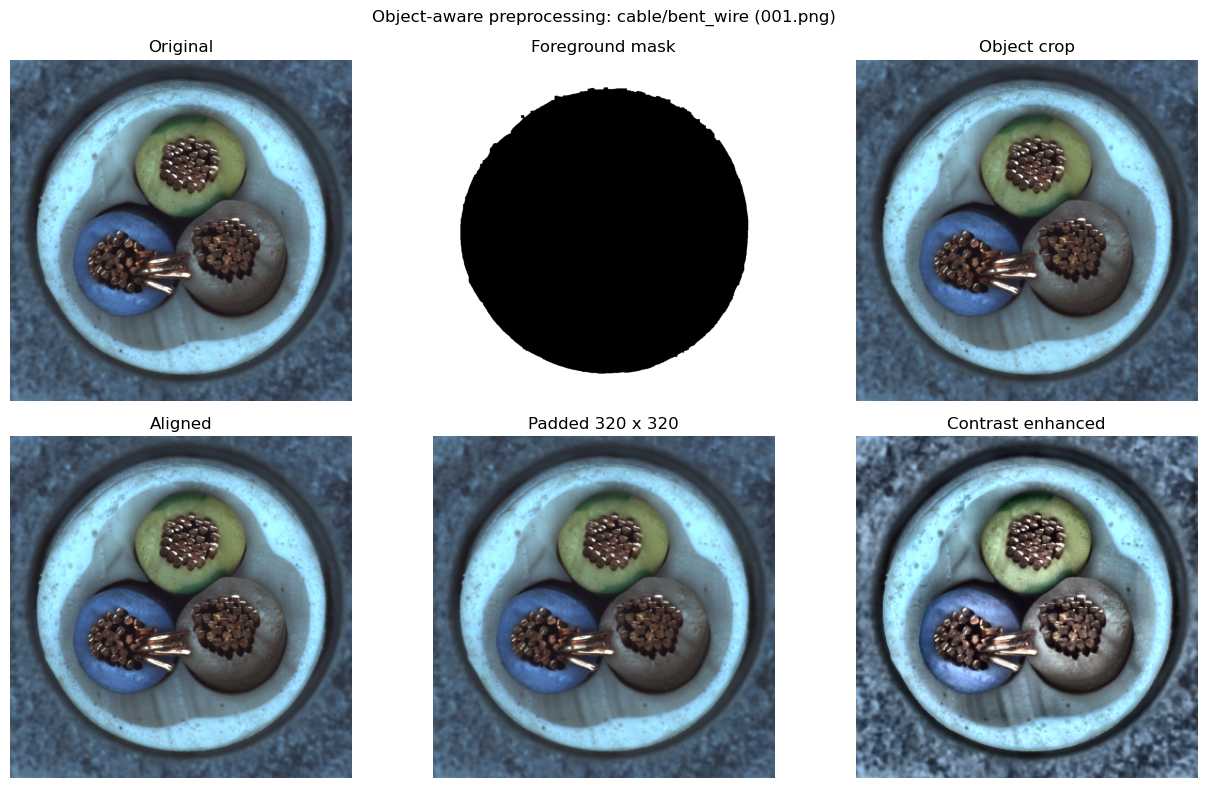

In [3]:
from ml.inference import baseline_anomaly_prediction
from ml.object_preprocessing import (
    align_crop_bgr,
    crop_to_mask,
    enhance_contrast_bgr,
    foreground_mask_bgr,
    resize_with_padding,
)

good_path = first_test_image(CATEGORY, "good")

# Use the first real cable defect that survives both detector gates. The
# all-category notebook later evaluates fixed samples and keeps misses visible.
defect_label = None
defect_path = None
for directory in sorted((DATASET_ROOT / CATEGORY / "test").iterdir()):
    if not directory.is_dir() or directory.name == "good":
        continue
    for candidate in image_files(directory)[:5]:
        candidate_bgr = cv2.imread(str(candidate))
        candidate_result = baseline_anomaly_prediction(candidate, candidate_bgr, config)
        if candidate_result["is_defective"]:
            defect_label, defect_path = directory.name, candidate
            break
    if defect_path is not None:
        break
if defect_path is None:
    raise RuntimeError("No detected cable defect was found in the diagnostic search window.")

image_bgr = cv2.imread(str(defect_path))
object_mask = foreground_mask_bgr(image_bgr)
cropped = crop_to_mask(image_bgr, object_mask)
aligned = align_crop_bgr(cropped)
resized = resize_with_padding(aligned, (320, 320))
enhanced = enhance_contrast_bgr(resized)

views = [
    ("Original", image_bgr),
    ("Foreground mask", object_mask.astype(np.uint8) * 255),
    ("Object crop", cropped),
    ("Aligned", aligned),
    ("Padded 320 x 320", resized),
    ("Contrast enhanced", enhanced),
]
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for axis, (title, value) in zip(axes.flat, views, strict=True):
    if value.ndim == 2:
        axis.imshow(value, cmap="gray")
    else:
        axis.imshow(cv2.cvtColor(value, cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis("off")
plt.suptitle(f"Object-aware preprocessing: {CATEGORY}/{defect_label} ({defect_path.name})")
plt.tight_layout()
plt.show()

In [4]:
from ml.inference import baseline_anomaly_prediction

evidence = []
predictions = {}
for expected, path in [("good", good_path), (defect_label, defect_path)]:
    image_bgr = cv2.imread(str(path))
    result = baseline_anomaly_prediction(path, image_bgr, config)
    predictions[expected] = result
    evidence.append(
        {
            "expected": expected,
            "file": path.name,
            "nearest-normal distance": round(result["anomaly_score"], 6),
            "global threshold": result["decision_threshold"],
            "residual p99": result["residual_score"],
            "localized pixels": int(np.asarray(result["pred_mask"]).sum()),
            "predicted": "Defective" if result["is_defective"] else "Good",
            "confidence": result["detection_confidence"],
        }
    )
display(pd.DataFrame(evidence))

,expected,file,nearest-normal distance,global threshold,residual p99,localized pixels,predicted,confidence
0,good,000.png,0.040136,0.041518,1.5574,1870,Good,0.5514
1,bent_wire,001.png,0.066544,0.041518,1.4363,1119,Defective,0.5750


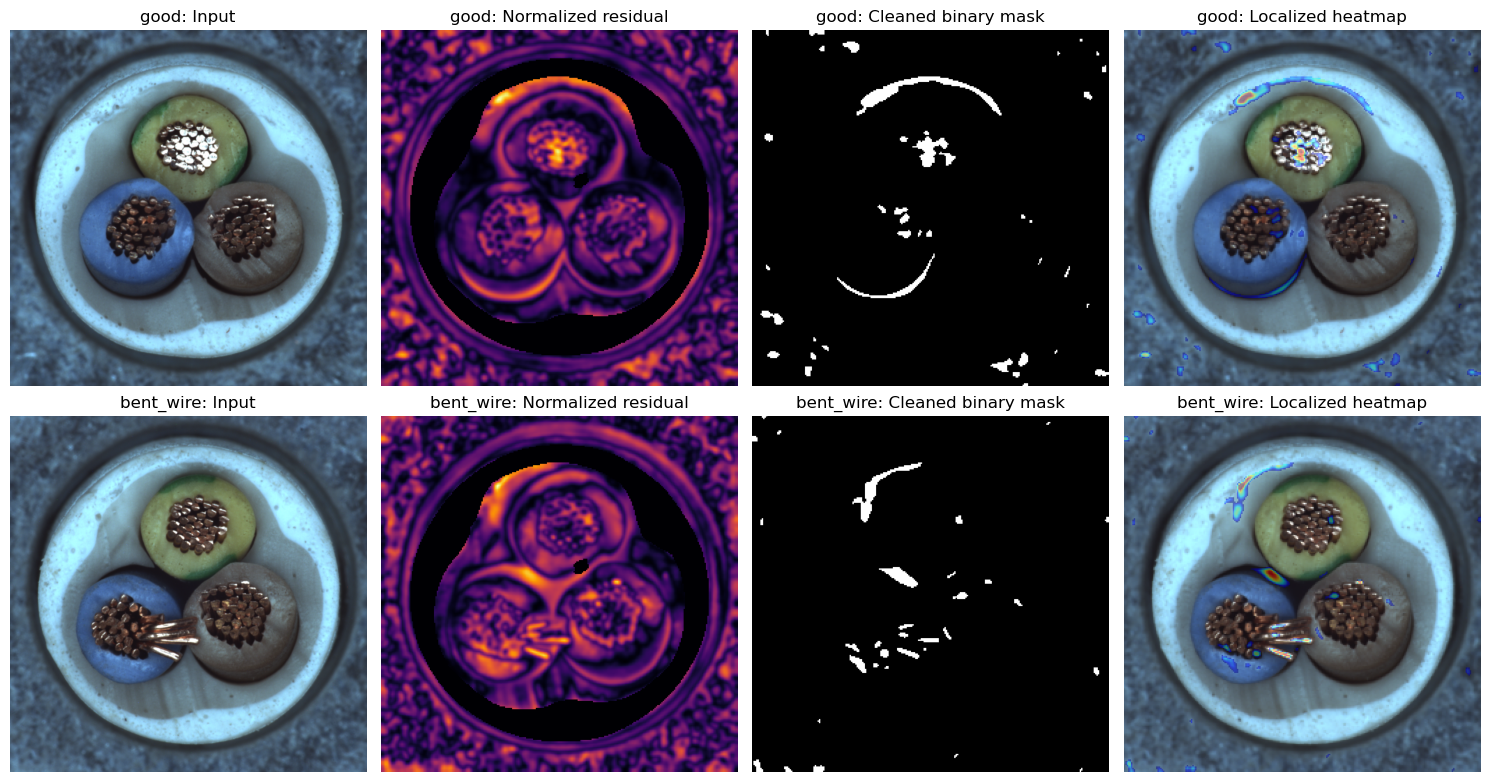

In [5]:
from ml.baseline_detector import heatmap_overlay

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for row_index, (label, path) in enumerate([("good", good_path), (defect_label, defect_path)]):
    image_bgr = cv2.imread(str(path))
    result = predictions[label]
    overlay = heatmap_overlay(image_bgr, result["anomaly_map"], binary_mask=result["pred_mask"])
    panels = [
        ("Input", cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB), None),
        ("Normalized residual", result["anomaly_map"], "inferno"),
        ("Cleaned binary mask", result["pred_mask"], "gray"),
        ("Localized heatmap", cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB), None),
    ]
    for column_index, (title, value, color_map) in enumerate(panels):
        axes[row_index, column_index].imshow(value, cmap=color_map)
        axes[row_index, column_index].set_title(f"{label}: {title}")
        axes[row_index, column_index].axis("off")
plt.tight_layout()
plt.show()

## Decision rule used in the application

```python
is_defective = (
    nearest_normal_cosine_distance > calibrated_global_threshold
    and cleaned_residual_mask_contains_pixels
)
```

The embedding score answers, “Does this image look unlike known normal products?” The residual mask answers, “Can the difference be localized to a meaningful region?” Both are required.

## What this demonstrates

- The baseline is not a single OpenCV threshold; it combines an ONNX deep embedding with category-specific normal memory.
- Illumination correction and normal variability reduce sensitivity to harmless brightness changes.
- Morphological cleanup and the two-gate rule reduce false alarms.
- The same output contract supplies the anomaly score, mask, confidence, and heatmap to later pipeline stages.